In [111]:
import pandas as pd
import numpy as np
import seaborn as sns
import pickle as pkl
import matplotlib.pyplot as plt

In [112]:
df = pd.read_csv("raw/B.csv")
df.head()


,student_id,gender,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,extracurricular_activities,placement_status,salary_package_lpa
0,1,Male,53,79,56,8.87,50,92,90,1,3,23,4,91,4,Yes,0,0.00
1,2,Female,56,54,59,6.78,61,51,99,1,0,6,5,87,3,No,0,0.00
2,3,Male,94,83,83,7.92,91,93,84,1,1,10,2,81,2,No,1,6.92
3,4,Male,84,71,87,6.57,85,60,72,4,2,14,5,87,3,No,0,0.00
4,5,Male,58,88,74,9.01,73,52,88,1,2,20,0,60,1,No,0,0.00


In [113]:
df.tail()

,student_id,gender,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,extracurricular_activities,placement_status,salary_package_lpa
4995,4996,Male,68,50,67,8.32,51,57,96,1,1,15,1,71,4,Yes,0,0.0
4996,4997,Female,61,52,56,9.47,61,59,62,3,4,0,3,73,5,Yes,0,0.0
4997,4998,Male,74,76,58,6.19,40,99,89,1,1,2,2,67,1,No,0,0.0
4998,4999,Female,84,67,66,8.07,40,48,92,4,1,6,4,61,0,No,0,0.0
4999,5000,Female,61,79,64,6.97,42,80,59,4,5,2,5,93,4,Yes,0,0.0


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  5000 non-null   int64  
 1   gender                      5000 non-null   object 
 2   ssc_percentage              5000 non-null   int64  
 3   hsc_percentage              5000 non-null   int64  
 4   degree_percentage           5000 non-null   int64  
 5   cgpa                        5000 non-null   float64
 6   entrance_exam_score         5000 non-null   int64  
 7   technical_skill_score       5000 non-null   int64  
 8   soft_skill_score            5000 non-null   int64  
 9   internship_count            5000 non-null   int64  
 10  live_projects               5000 non-null   int64  
 11  work_experience_months      5000 non-null   int64  
 12  certifications              5000 non-null   int64  
 13  attendance_percentage       5000 

1. [LO 1, LO 2 - Bobot: 25%] Exploratory Data Analysis & Modeling (.ipynb) 

Feature Engineering (Hapus kolom ID)

In [115]:
df.drop(['student_id'], axis=1, inplace=True)

In [116]:
df['academic_score'] = (
    df['ssc_percentage'] + 
    df['hsc_percentage'] + 
    df['degree_percentage'] + 
    df['cgpa']*10
) / 4

Cek NULL 

In [117]:
df.isnull().sum()

gender                        0
ssc_percentage                0
hsc_percentage                0
degree_percentage             0
cgpa                          0
entrance_exam_score           0
technical_skill_score         0
soft_skill_score              0
internship_count              0
live_projects                 0
work_experience_months        0
certifications                0
attendance_percentage         0
backlogs                      0
extracurricular_activities    0
placement_status              0
salary_package_lpa            0
academic_score                0
dtype: int64

Hapus duplikat jika ada

In [118]:
df = df.drop_duplicates()

Cek outlier

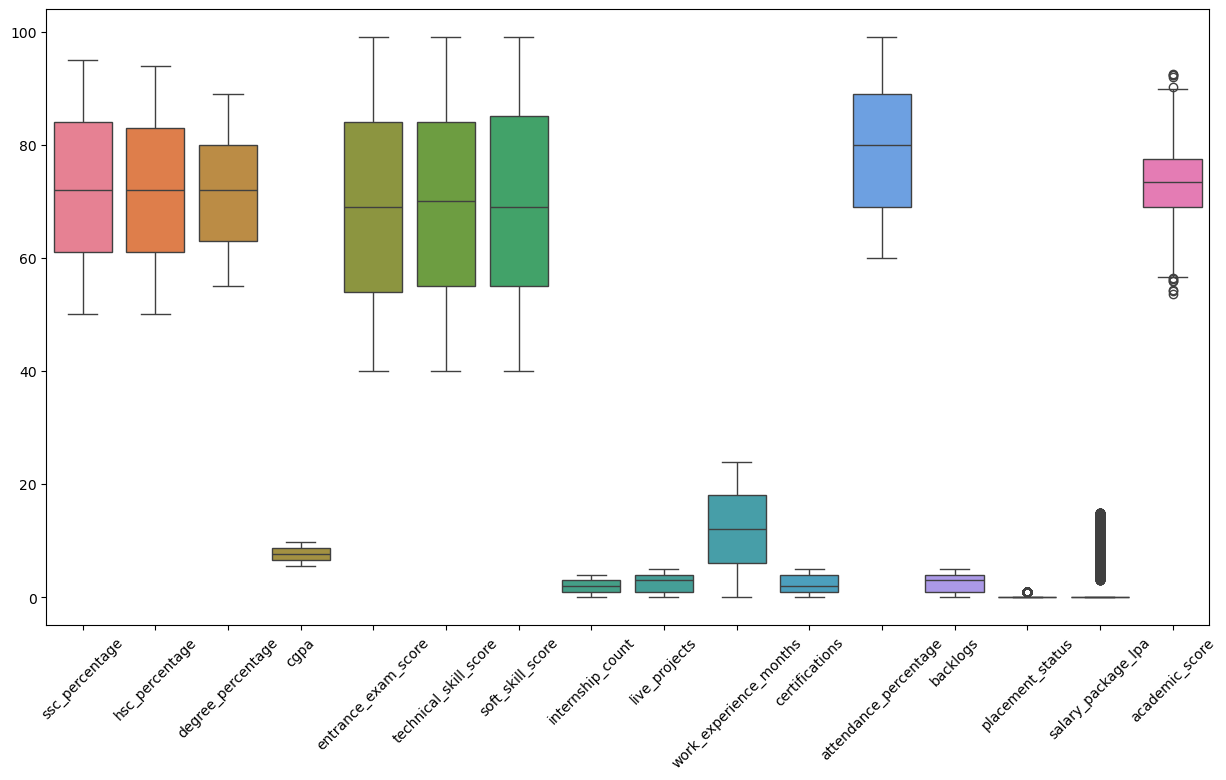

In [119]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15,8))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=45)
plt.show()

Cek Kolerasi

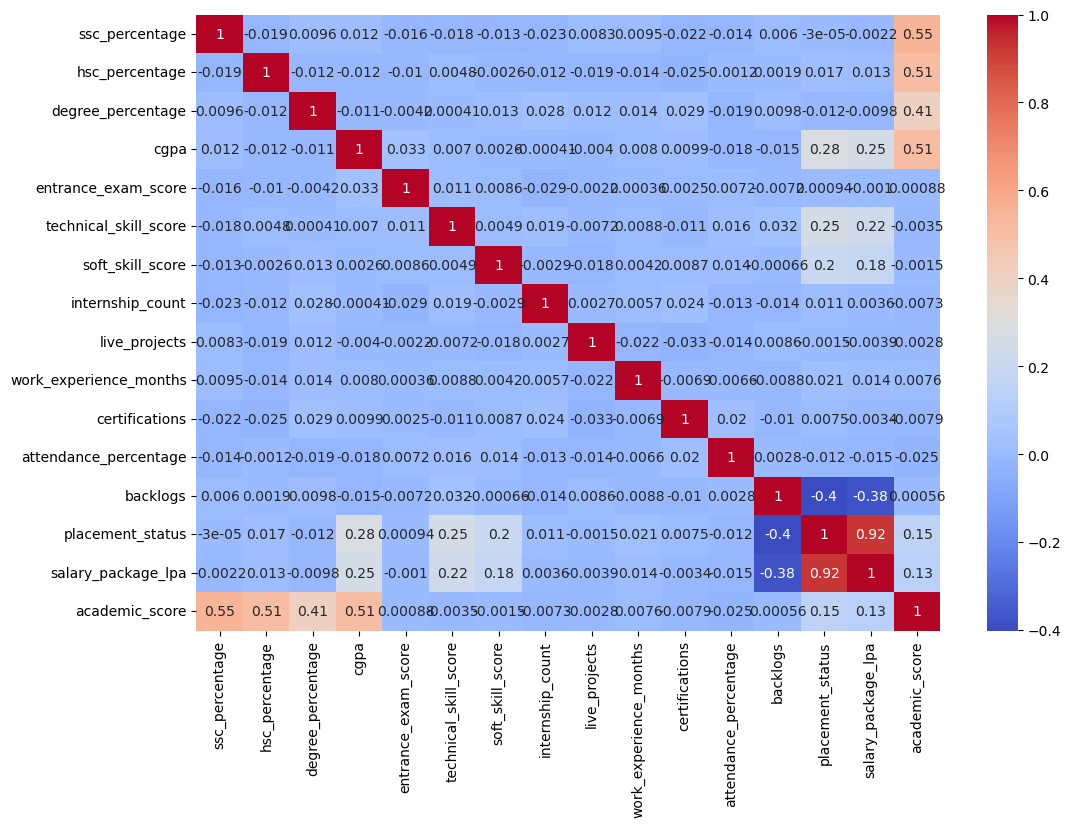

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

# ambil hanya kolom numerik
df_temp = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(df_temp.corr(), annot=True, cmap='coolwarm')
plt.show()

Split data 80:20


In [121]:
from sklearn.model_selection import train_test_split

X       = df.drop(['placement_status', 'salary_package_lpa'], axis=1)
y_class = df['placement_status']
y_reg   = df['salary_package_lpa']

X_train, X_test, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

y_train_r = y_reg.loc[y_train_c.index]
y_test_r  = y_reg.loc[y_test_c.index]

print(f'Train : {X_train.shape}')
print(f'Test  : {X_test.shape}')
print(f'Distribusi kelas train : {y_train_c.value_counts().to_dict()}')
print(f'Distribusi kelas test  : {y_test_c.value_counts().to_dict()}')

Train : (4000, 16)
Test  : (1000, 16)
Distribusi kelas train : {0: 3307, 1: 693}
Distribusi kelas test  : {0: 827, 1: 173}


In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['gender', 'extracurricular_activities']

encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_train = encoder.fit_transform(X_train[categorical_cols])
encoded_test = encoder.transform(X_test[categorical_cols])

encoded_df_train = pd.DataFrame(encoded_train, columns=encoder.get_feature_names_out(categorical_cols), index=X_train.index)
encoded_df_test = pd.DataFrame(encoded_test, columns=encoder.get_feature_names_out(categorical_cols), index=X_test.index)

X_train = pd.concat([X_train.drop(columns=categorical_cols), encoded_df_train], axis=1)
X_test = pd.concat([X_test.drop(columns=categorical_cols), encoded_df_test], axis=1)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

feature_names = X_train.columns.tolist()

B. Modeling: Bangun dan bandingkan minimal tiga algoritma untuk masing-masing tugas 
(Klasifikasi & Regresi). 

In [124]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
from xgboost import XGBClassifier, XGBRegressor

Klasifikasi

In [125]:
models_class = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'            : XGBClassifier(n_estimators=200,max_depth=5,learning_rate=0.1,random_state=42)
}

results_class = {}
trained_class = {}
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models_class.items():
    model.fit(X_train_scaled, y_train_c)
    y_pred = model.predict(X_test_scaled)
    trained_class[name] = model

    acc = accuracy_score(y_test_c, y_pred)
    f1  = f1_score(y_test_c, y_pred)

    cv_acc = cross_val_score(model, X_train_scaled, y_train_c, cv=cv_strat, scoring='accuracy')
    cv_f1  = cross_val_score(model, X_train_scaled, y_train_c, cv=cv_strat, scoring='f1')

    results_class[name] = {
        'Test Accuracy': round(acc, 4),
        'Test F1 Score': round(f1, 4),
        'CV Accuracy'  : f'{cv_acc.mean():.4f} ± {cv_acc.std():.4f}',
        'CV F1 Score'  : f'{cv_f1.mean():.4f} ± {cv_f1.std():.4f}'
    }

pd.DataFrame(results_class).T

,Test Accuracy,Test F1 Score,CV Accuracy,CV F1 Score
Logistic Regression,0.891,0.6583,0.8902 ± 0.0101,0.6470 ± 0.0276
Random Forest,1.0,1.0,0.9995 ± 0.0006,0.9986 ± 0.0018
XGBoost,1.0,1.0,0.9998 ± 0.0005,0.9993 ± 0.0014


Regression

In [126]:
# Filter hanya data placed
train_placed_idx = y_train_r[y_train_r > 0].index
test_placed_idx  = y_test_r[y_test_r > 0].index

X_train_reg = X_train.loc[train_placed_idx]
X_test_reg  = X_test.loc[test_placed_idx]
y_train_reg = y_train_r.loc[train_placed_idx]
y_test_reg  = y_test_r.loc[test_placed_idx]

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled  = scaler_reg.transform(X_test_reg)

print(f'Train regresi: {X_train_reg.shape}')
print(f'Test  regresi: {X_test_reg.shape}')

Train regresi: (693, 16)
Test  regresi: (173, 16)


In [127]:
import numpy as np
import pandas as pd

from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_absolute_error

# =========================
# 0. FILTER DATA (ONLY PLACED)
# =========================
mask_train = y_train_c == 1
mask_test  = y_test_c == 1

X_train_reg = X_train.loc[mask_train]
X_test_reg  = X_test.loc[mask_test]

y_train_reg = y_train_r.loc[mask_train]
y_test_reg  = y_test_r.loc[mask_test]

print("Train:", X_train_reg.shape)
print("Test :", X_test_reg.shape)

# =========================
# 1. MODELS + HYPERPARAMETER SPACE
# =========================

# ---- RANDOM FOREST TUNING ----
rf = RandomForestRegressor(random_state=42)

rf_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    rf,
    rf_params,
    n_iter=10,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

# ---- XGBOOST TUNING ----
xgb = XGBRegressor(random_state=42)

xgb_params = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [3, 4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb,
    xgb_params,
    n_iter=10,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

# =========================
# 2. TRAIN MODELS
# =========================

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest (Tuned)": rf_search,
    "XGBoost (Tuned)": xgb_search
}

results = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train_reg, y_train_reg)

    y_pred = model.predict(X_test_reg)

    r2 = r2_score(y_test_reg, y_pred)
    mae = mean_absolute_error(y_test_reg, y_pred)

    results[name] = {
        "R2": r2,
        "MAE": mae
    }

    print(f"{name} DONE")

# =========================
# 3. RESULT
# =========================

print("\n=== HASIL FINAL (WITH HYPERTUNING) ===")
for name, res in results.items():
    print(f"\n{name}")
    print(f"R2  : {res['R2']:.4f}")
    print(f"MAE : {res['MAE']:.4f}")

Train: (693, 16)
Test : (173, 16)

Training Linear Regression...
Linear Regression DONE

Training Random Forest (Tuned)...
Random Forest (Tuned) DONE

Training XGBoost (Tuned)...


c:\Users\Felix yung\anaconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


XGBoost (Tuned) DONE

=== HASIL FINAL (WITH HYPERTUNING) ===

Linear Regression
R2  : -0.0111
MAE : 2.8870

Random Forest (Tuned)
R2  : -0.0411
MAE : 2.9154

XGBoost (Tuned)
R2  : -0.0704
MAE : 2.9575


Ringkasan hasil

In [128]:
print('=' * 55)
print('KLASIFIKASI — Placement Status')
print('=' * 55)
print(pd.DataFrame(results_class).T.to_string())

print()
print('=' * 55)
print('REGRESI — Salary Package (LPA)')
print('=' * 55)

df_reg = pd.DataFrame(results).T
print(df_reg.to_string())

KLASIFIKASI — Placement Status
                    Test Accuracy Test F1 Score      CV Accuracy      CV F1 Score
Logistic Regression         0.891        0.6583  0.8902 ± 0.0101  0.6470 ± 0.0276
Random Forest                 1.0           1.0  0.9995 ± 0.0006  0.9986 ± 0.0018
XGBoost                       1.0           1.0  0.9998 ± 0.0005  0.9993 ± 0.0014

REGRESI — Salary Package (LPA)
                             R2       MAE
Linear Regression     -0.011105  2.887013
Random Forest (Tuned) -0.041149  2.915366
XGBoost (Tuned)       -0.070449  2.957498


Model yang saya pilih:

klasifikasi = XgBoost Classifier

regresi = Linear Regression